## **Kelompok 14**

Nama Anggota :


1.   M. Rivaldi Mahari (18222119)
2.   I Nyoman Rai Dharma Wiguna (18223083)



# Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Unggah ke Google Colab dulu CSV-nya!

In [ ]:
filename = "cars.csv"
df = pd.read_csv(filename)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


### Data Understanding

In [ ]:
df['price'].unique()

array(['13495', '16500', '13950', '17450', '15250', '17710', '18920',
       '23875', '?', '16430', '16925', '20970', '21105', '24565', '30760',
       '41315', '36880', '5151', '6295', '6575', '5572', '6377', '7957',
       '6229', '6692', '7609', '8558', '8921', '12964', '6479', '6855',
       '5399', '6529', '7129', '7295', '7895', '9095', '8845', '10295',
       '12945', '10345', '6785', '11048', '32250', '35550', '36000',
       '5195', '6095', '6795', '6695', '7395', '10945', '11845', '13645',
       '15645', '8495', '10595', '10245', '10795', '11245', '18280',
       '18344', '25552', '28248', '28176', '31600', '34184', '35056',
       '40960', '45400', '16503', '5389', '6189', '6669', '7689', '9959',
       '8499', '12629', '14869', '14489', '6989', '8189', '9279', '5499',
       '7099', '6649', '6849', '7349', '7299', '7799', '7499', '7999',
       '8249', '8949', '9549', '13499', '14399', '17199', '19699',
       '18399', '11900', '13200', '12440', '13860', '15580', '16900',


In [ ]:
df.replace("?", np.nan, inplace = True) # Mengganti tanda "?" menjadi NaN

In [ ]:
df['price'].isnull().sum() # Menghitung jumlah nilai yang hilang

np.int64(4)

In [ ]:
df[["price"]] = df[["price"]].astype("float") #Karena price bertipe object, kita harus mengonversinya ke float untuk proses analisis lebih lanjut.

In [ ]:
df.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


### Preprocessing Data

In [ ]:
import numpy as np

# preproses
df.replace("?", np.nan, inplace = True) #Mengganti Tanda “?” dengan NaN
df.dropna(subset=["price"], axis=0, inplace=True) #Menghapus Baris dengan Nilai Hilang pada Kolom price

# Mereset Indeks
# Setelah beberapa baris dihapus, indeks baris pada DataFrame menjadi tidak berurutan. reset_index digunakan untuk mengatur ulang indeks sehingga kembali berurutan.
df.reset_index(drop=True, inplace=True)
df.shape

# Mengonversi Kolom price Menjadi Tipe Data Numerik
df[["price"]] = df[["price"]].astype("float")

In [ ]:
df.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [ ]:
df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg', 'price']].head()

,horsepower,curb-weight,engine-size,highway-mpg,price
0,111,2548,130,27,13495.0
1,111,2548,130,27,16500.0
2,154,2823,152,26,16500.0
3,102,2337,109,30,13950.0
4,115,2824,136,22,17450.0


### Regresi Linear

Pada kode ini, kita membuat model Regresi Linear Sederhana untuk memprediksi harga mobil (price) berdasarkan variabel highway-mpg. Berikut adalah penjelasan setiap langkah dan hasil yang diperoleh:

In [ ]:
from sklearn.linear_model import LinearRegression

X = df[['highway-mpg']]
Y = df['price']

lm = LinearRegression()
lm.fit(X,Y)
print('Dataset lengkap: ',df.shape)
print('Training data: ',X.shape)
print('Koefisien: ',lm.coef_)
print('Intercept: ',lm.intercept_)

Dataset lengkap:  (201, 26)
Training data:  (201, 1)
Koefisien:  [-821.73337832]
Intercept:  38423.3058581574


X = df[['highway-mpg']]: Variabel X berisi kolom highway-mpg yang digunakan sebagai fitur independen. <br>
Y = df['price']: Variabel Y adalah harga mobil (price) sebagai variabel target yang ingin diprediksi. <br>
lm = LinearRegression(): Membuat objek model regresi linear. <br>
lm.fit(X, Y): Melatih model dengan data X dan Y. <br>
print(...): Menampilkan informasi tentang dataset, koefisien (slope), dan intercept (y-intercept) dari model.<br> <br>

**Hasil:** <br>
Dataset lengkap memiliki 201 baris dan 26 kolom (df.shape: (201, 26)). <br>
Data untuk pelatihan terdiri dari 201 baris dengan 1 fitur (X.shape: (201, 1)). <br>

**Model regresi linear menghasilkan persamaan garis lurus dalam bentuk:** <br>

price = (koefisien×highway-mpg)+intercept <br><br>

. Koefisien (-821.73337832) <br><br>
Koefisien adalah nilai kemiringan (slope) dari garis regresi yang menunjukkan perubahan variabel target (price) untuk setiap perubahan satu unit dalam highway-mpg.  <br>
Dalam hal ini, nilai koefisien sebesar -821.73337832 menunjukkan bahwa: <br>
Setiap peningkatan 1 unit pada highway-mpg (misalnya dari 30 menjadi 31 mpg) diasosiasikan dengan penurunan harga mobil (price) sebesar sekitar 821.73 dolar.  <br><br>
Tanda negatif (-) menunjukkan hubungan berlawanan antara highway-mpg dan price. Artinya, semakin tinggi nilai highway-mpg (yang umumnya berarti mobil lebih hemat bahan bakar), maka harga mobil cenderung lebih rendah.  <br>  <br>
Secara umum, hasil ini menunjukkan bahwa dalam dataset ini, mobil dengan efisiensi bahan bakar yang lebih tinggi (highway-mpg lebih tinggi) cenderung memiliki harga yang lebih rendah. <br>  <br>


.  Intercept: 38423.31 <br>
Intercept adalah titik potong garis regresi pada sumbu price ketika highway-mpg bernilai 0. <br>
Nilai intercept sebesar 38423.31 berarti bahwa jika highway-mpg bernilai 0 (meskipun dalam konteks ini nilai 0 tidak realistis untuk mpg), model memprediksi bahwa harga mobil akan mendekati $38,423.31. <br>
Intercept ini biasanya tidak memiliki interpretasi yang langsung jika nilai 0 untuk highway-mpg tidak masuk akal, tetapi penting dalam membentuk garis regresi secara keseluruhan.


<Axes: xlabel='highway-mpg', ylabel='price'>

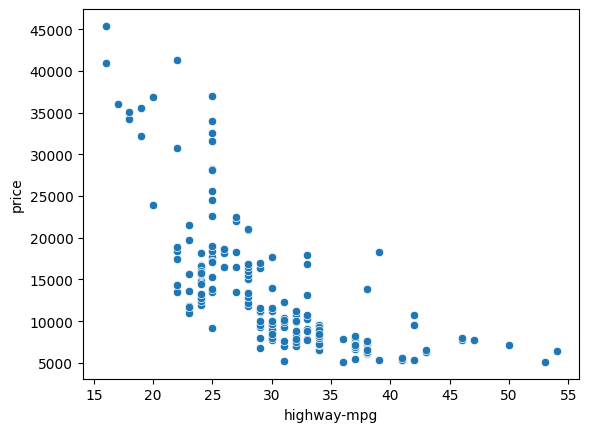

In [ ]:
import seaborn as sns
sns.scatterplot(data=df, x="highway-mpg", y="price")

(0.0, 48179.561473109636)

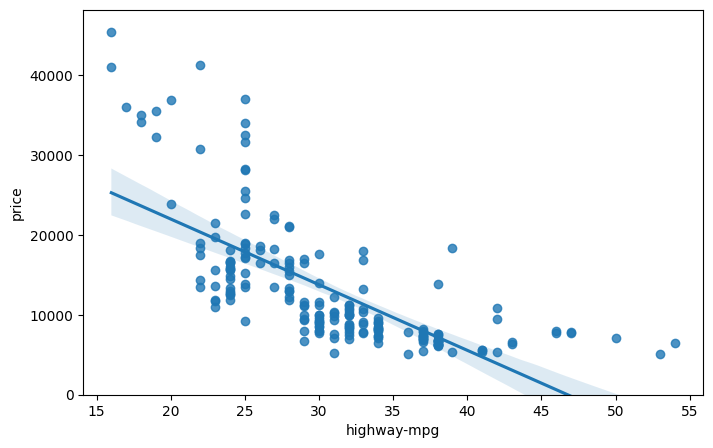

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)

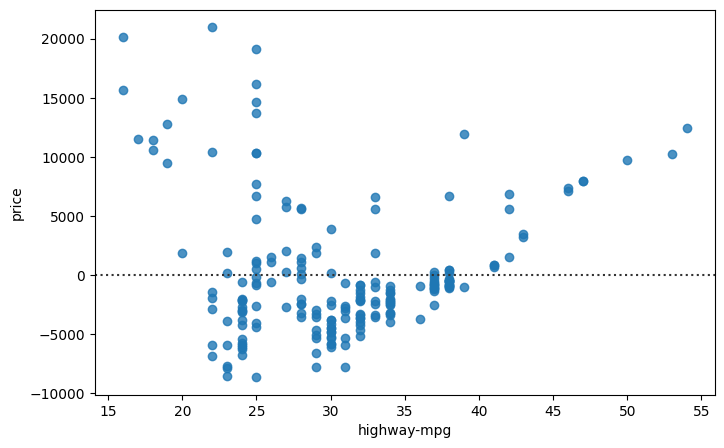

In [ ]:
plt.figure(figsize=(8,5))
sns.residplot(x=df['highway-mpg'], y=df['price'])
plt.show()

/tmp/ipykernel_7578/588266299.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
/tmp/ipykernel_7578/588266299.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values

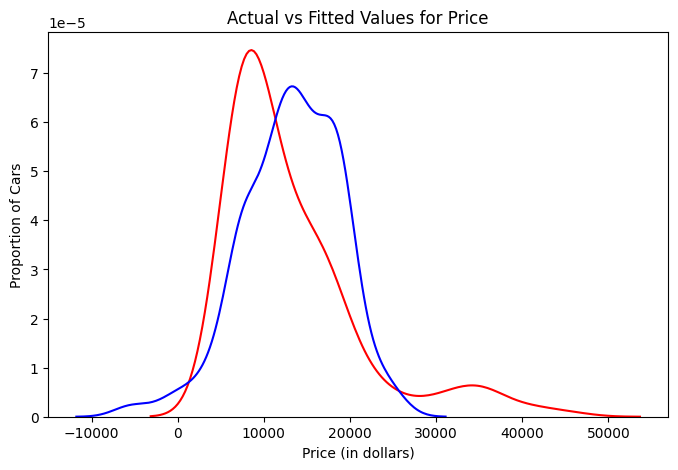

In [ ]:
Y_hat = lm.predict(X)

plt.figure(figsize=(8,5))
ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

Y_hat = lm.predict(X): Menggunakan model untuk memprediksi harga mobil (price) berdasarkan X. <br>
sns.distplot(...): Menampilkan distribusi nilai price aktual (df['price']) dengan garis merah dan nilai prediksi (Y_hat) dengan garis biru. <br>
Grafik ini membantu kita melihat sejauh mana prediksi model mendekati nilai price yang sebenarnya.

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(df[['highway-mpg']])
test_y = np.asanyarray(df[['price']])
test_y_ = lm.predict(df[['highway-mpg']])

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 7365.94
Residual sum of squares (MSE): 94048267.39
R2-score: -0.01


test_x: Merupakan array dari data highway-mpg sebagai variabel independen atau input untuk model prediksi. <br>
test_y: Merupakan array dari data price sebagai variabel target atau output yang sebenarnya (actual values). <br>
test_y_: Merupakan array dari hasil prediksi model (lm.predict) terhadap test_x. Ini berisi nilai harga mobil yang diprediksi oleh model berdasarkan highway-mpg <br> <br>

Menghitung Metrik Evaluasi <br>

*   MAE mengukur rata-rata nilai absolut dari selisih antara nilai prediksi dan nilai aktual.
*   MSE mengukur rata-rata dari kuadrat selisih antara nilai prediksi dan nilai aktual.
*   R2-score mengukur seberapa baik model mampu menjelaskan variabilitas dalam data target. <br> <br>

Jika hasilnya adalah: <br>
*   MAE tinggi berarti prediksi model kurang akurat.
*   MSE tinggi menandakan kesalahan kuadrat yang besar pada prediksi.
*   R2-score negatif atau mendekati 0 menunjukkan model tidak menjelaskan variabilitas data dengan baik, atau performa model tidak lebih baik dibandingkan dengan prediksi rata-rata. <br> <br>

Hasil: <br>
*   Mean Absolute Error: 7365.94, menunjukkan bahwa rata-rata kesalahan prediksi harga mobil adalah sekitar $7,365.94.
*   MSE: 94048267.39, menunjukkan besarnya kesalahan prediksi dalam satuan kuadrat.
*   R2-score: -0.01, menunjukkan bahwa model ini tidak berhasil memprediksi data dengan baik. Nilai R2 yang negatif berarti model regresi linear sederhana ini kurang cocok untuk data tersebut. Dalam kasus ini, skor negatif pada R2 mengindikasikan bahwa model ini mungkin kurang cocok untuk memprediksi harga mobil berdasarkan highway-mpg saja.

### Multiple Linear Regression

Pada bagian ini, kita membangun model Multiple Linear Regression (Regresi Linear Berganda) untuk memprediksi harga mobil (price) berdasarkan beberapa variabel independen: horsepower, curb-weight, engine-size, dan highway-mpg. Berikut adalah penjelasan rinci untuk setiap langkah, beserta hasil dan interpretasi dari metrik evaluasi.

In [ ]:
avg_horsepower = df['horsepower'].astype('float').mean() #Menghitung rata-rata horsepower pada dataset dan menyimpan hasilnya di variabel avg_horsepower
print("Average horsepower:", avg_horsepower)
df['horsepower'].replace(np.nan, avg_horsepower, inplace=True) #Jika terdapat nilai NaN pada kolom horsepower, nilai tersebut diganti dengan nilai rata-rata ini. Hal ini dilakukan untuk menjaga data tetap lengkap, sehingga tidak ada baris data yang dibuang karena nilai kosong.

Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']] #Z adalah variabel independen yang mencakup empat fitur: horsepower, curb-weight, engine-size, dan highway-mpg.
Y = df['price'] #Y adalah variabel dependen (target), yaitu price.

lm_mv = LinearRegression() #Model regresi linear berganda dilatih dengan memetakan Z ke Y menggunakan LinearRegression().
lm_mv.fit(Z,Y)
print('Dataset lengkap: ',df.shape)
print('Training data: ',X.shape)
print('Koefisien: ',lm_mv.coef_)
print('Intercept: ',lm_mv.intercept_)

Average horsepower: 103.39698492462311
Dataset lengkap:  (201, 26)
Training data:  (201, 1)
Koefisien:  [53.61042729  4.70886444 81.47225667 36.39637823]
Intercept:  -15824.03820823447


/tmp/ipykernel_7578/3551811811.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].replace(np.nan, avg_horsepower, inplace=True) #Jika terdapat nilai NaN pada kolom horsepower, nilai tersebut diganti dengan nilai rata-rata ini. Hal ini dilakukan untuk menjaga data tetap lengkap, sehingga tidak ada baris data yang dibuang karena nilai kosong.


Koefisien: [53.61, 4.71, 81.47, 36.40]
*   53.61 (koefisien horsepower): Setiap peningkatan 1 unit dalam horsepower diasosiasikan dengan kenaikan harga mobil sekitar $53.61.<br>
*   4.71 (koefisien curb-weight): Setiap kenaikan 1 unit pada curb-weight dikaitkan dengan peningkatan harga mobil sekitar $4.71. <br>
*   81.47 (koefisien engine-size): Setiap peningkatan 1 unit dalam engine-size diasosiasikan dengan kenaikan harga mobil sebesar $81.47. <br>
*   36.40 (koefisien highway-mpg): Setiap kenaikan 1 unit highway-mpg dikaitkan dengan kenaikan harga mobil sekitar $36.40. <br><br>

Intercept: -15824.04 <br>
Ini adalah harga dasar mobil ketika semua fitur bernilai 0, yang dalam konteks ini tidak selalu bermakna langsung, tetapi penting untuk perhitungan prediksi harga.

/tmp/ipykernel_7578/485738449.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
/tmp/ipykernel_7578/485738449.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_hat_mv, hist=False, color="b", label="Fitted Val

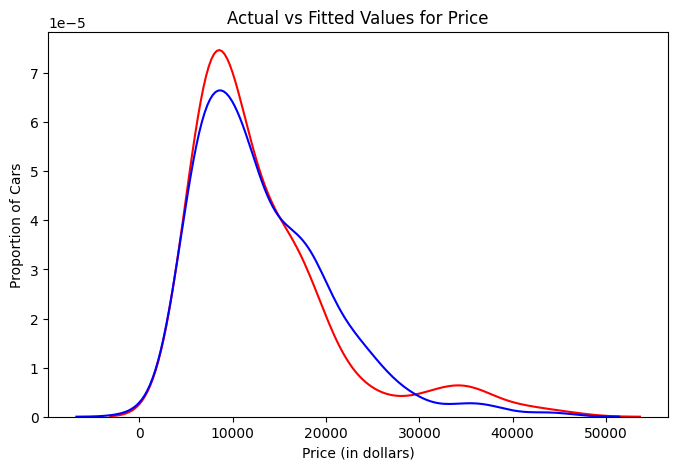

In [ ]:
Y_hat_mv = lm_mv.predict(Z)

plt.figure(figsize=(8,5))
ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(Y_hat_mv, hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

Plot ini membandingkan nilai aktual (price) dengan nilai prediksi (Y_hat_mv). <br>
Garis merah menunjukkan nilai harga aktual, sedangkan garis biru adalah nilai prediksi model. <br>
Jika kedua garis ini saling tumpang tindih atau dekat satu sama lain, itu menunjukkan bahwa model cukup baik dalam mendekati nilai aktual.

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(Z)
test_y = np.asanyarray(Y)
test_y_ = lm_mv.predict(Z)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 2450.43
Residual sum of squares (MSE): 11976801.68
R2-score: 0.76


Hasil:

Mean Absolute Error (MAE): 2450.43 <br>

MAE menunjukkan rata-rata kesalahan absolut antara prediksi dan nilai aktual, dalam satuan dolar. Nilai MAE sekitar 2450 menunjukkan bahwa model, rata-rata, memiliki kesalahan prediksi sebesar 2450.  <br> <br>

Mean Squared Error (MSE): 11976801.68  <br>
MSE adalah rata-rata dari kuadrat selisih antara nilai prediksi dan nilai aktual. MSE yang rendah menunjukkan bahwa model relatif akurat dalam memprediksi harga.  <br> <br>

R2-score: 0.76  <br>

R2-score (koefisien determinasi) mengukur seberapa baik model menjelaskan variabilitas data target (price). Nilai 0,76 berarti bahwa sekitar 76% dari variabilitas dalam price dapat dijelaskan oleh model ini. Semakin dekat ke 1, semakin baik model menjelaskan data. Nilai ini menunjukkan performa yang cukup baik untuk model regresi linear berganda ini.  <br>

### Polynomial Regression

Pada bagian ini, kita menggunakan Polynomial Regression (Regresi Polinomial) untuk memodelkan hubungan antara highway-mpg (konsumsi bahan bakar di jalan raya) dan price (harga mobil). Berbeda dengan regresi linear sederhana, regresi polinomial memungkinkan kita untuk menangkap hubungan non-linear antara variabel independen dan dependen.

In [ ]:
X = df['highway-mpg']
Y = df['price']

f = np.polyfit(X, Y, 3) #menghitung koefisien untuk polinomial derajat (degree) 3 yang paling sesuai antara highway-mpg dan price. (X, Y, degree)
p = np.poly1d(f) #membuat fungsi polinomial berdasarkan koefisien yang dihasilkan.
print(p)

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


Hasil yang didapatkan adalah persamaan polinomial berikut:
−1.557𝑥^3+204.8𝑥^2−8965^𝑥+137900 <br>

Di sini,
x merepresentasikan variabel highway-mpg, yang merupakan konsumsi bahan bakar di jalan raya dan hasil dari persamaan ini adalah harga perkiraan mobil dalam dataset.



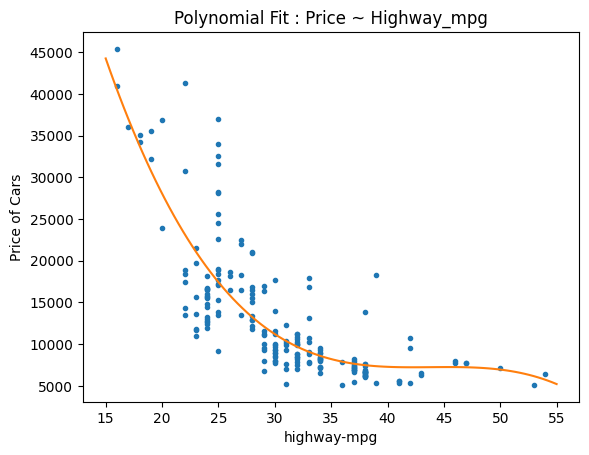

In [ ]:
def PlotPolly(model, independent_variable, dependent_variabble, Name): #memvisualisasikan kurva regresi polinomial di atas titik-titik data aktual.
    x_new = np.linspace(15, 55, 100) #Fungsi np.linspace() dari NumPy ini menghasilkan 100 nilai yang terdistribusi secara merata di antara angka 15 dan 55.
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit : Price ~ Highway_mpg')
    ax = plt.gca()
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close()

PlotPolly(p, X, Y, 'highway-mpg')

Fungsi PlotPolly memvisualisasikan kurva regresi polinomial di atas titik-titik data aktual. <br>
Kurva polinomial dihasilkan oleh y_new = model(x_new), yang menunjukkan hubungan antara highway-mpg dan price.<br>
Grafik ini membantu kita melihat bahwa model polinomial mampu mencocokkan data dengan lebih baik dibandingkan regresi linear, terutama jika data memiliki pola non-linear.<br>

/tmp/ipykernel_7578/3552476085.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
/tmp/ipykernel_7578/3552476085.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(p(X), hist=False, color="b", label="Fitted Value

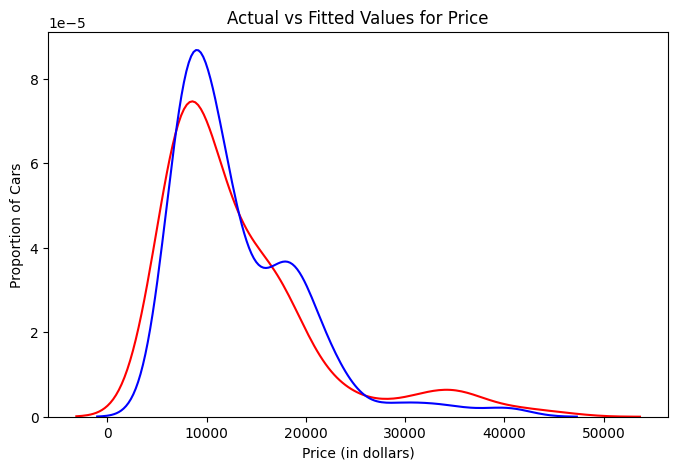

In [ ]:
plt.figure(figsize=(8, 5))

ax1 = sns.distplot(df['price'], hist=False, color="r", label="Actual Value")
sns.distplot(p(X), hist=False, color="b", label="Fitted Values" , ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()
plt.close()

In [ ]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(X)
test_y = np.asanyarray(Y)
test_y_ = p(X)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 2951.93
Residual sum of squares (MSE): 20474146.43
R2-score: 0.52


Hasil Evaluasi <br> <br>

Mean Absolute Error (MAE): 2951.93 <br>

Rata-rata kesalahan absolut antara nilai aktual dan prediksi adalah sekitar $2951.93. Angka ini lebih besar daripada regresi linear berganda, menunjukkan model ini memiliki kesalahan yang sedikit lebih besar. <br><br>

Mean squared error (MSE): 20474146.43 <br>

MSE ini lebih tinggi dibandingkan dengan regresi linear berganda, mengindikasikan bahwa model polinomial ini mungkin tidak seakurat model regresi berganda dalam memprediksi harga. <br><br>

R2-score: 0.52 <br>

R2-score sebesar 0,52 menunjukkan bahwa hanya 52% variabilitas dalam price yang dapat dijelaskan oleh highway-mpg melalui model polinomial ini. Nilai R2 ini lebih rendah dibandingkan dengan regresi linear berganda (0,76), mengindikasikan bahwa mungkin ada fitur-fitur lain yang lebih baik menjelaskan harga mobil daripada highway-mpg saja.

### Perbandingan Antar Model



1.   Regresi Linear (Linear Regression)
*    Model ini digunakan untuk memprediksi variabel dependen (Y) yang memiliki hubungan linear dengan satu variabel independen (X).
*    Hubungan antara variabel independen dan dependen adalah linier (garis lurus).

2.   Regresi Linear Berganda (Multiple Linear Regression)
*    Model ini digunakan ketika ada lebih dari satu variabel independen yang mempengaruhi variabel dependen. Ini cocok ketika hubungan antara variabel dependen dan independen lebih kompleks tetapi masih dapat dianggap linear.
*    Hubungan antara variabel dependen dan independen tetap linear meskipun ada beberapa variabel independen.
3.   Regresi Polinomial (Polynomial Regression)
*     Model ini digunakan untuk menangani hubungan yang non-linear antara variabel dependen dan independen. Regresi polinomial memperluas regresi linear dengan menambahkan istilah polinomial dari variabel independen.
*     Hubungan antara variabel dependen dan independen dapat berupa kurva (non-linear), tergantung pada derajat polinomial yang digunakan.



# Time Series Forecasting

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('international-airline-passengers.csv')
print('Number of rows and columns:', df.shape)
df.head(12)

Number of rows and columns: (145, 2)


,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0
5,1949-06,135.0
6,1949-07,148.0
7,1949-08,148.0
8,1949-09,136.0
9,1949-10,119.0


In [ ]:
df.tail(5)

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [ ]:
df.describe()

,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [ ]:
df=df.rename(columns={"International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60": "passenger"})
df = df.dropna()

## 0. Persiapan Data Sequence
Time-series forecasting model membutuhkan data berlabel. Untuk itu, disiapkan data dari time-series data yang tidak berlabel. Pendekatan ini disebut juga self-supervised learning.

In [ ]:
dataset = df.loc[:, ["passenger"]].values
print(dataset.shape)
dataset

(144, 1)


array([[112.],
       [118.],
       [132.],
       [129.],
       [121.],
       [135.],
       [148.],
       [148.],
       [136.],
       [119.],
       [104.],
       [118.],
       [115.],
       [126.],
       [141.],
       [135.],
       [125.],
       [149.],
       [170.],
       [170.],
       [158.],
       [133.],
       [114.],
       [140.],
       [145.],
       [150.],
       [178.],
       [163.],
       [172.],
       [178.],
       [199.],
       [199.],
       [184.],
       [162.],
       [146.],
       [166.],
       [171.],
       [180.],
       [193.],
       [181.],
       [183.],
       [218.],
       [230.],
       [242.],
       [209.],
       [191.],
       [172.],
       [194.],
       [196.],
       [196.],
       [236.],
       [235.],
       [229.],
       [243.],
       [264.],
       [272.],
       [237.],
       [211.],
       [180.],
       [201.],
       [204.],
       [188.],
       [235.],
       [227.],
       [234.],
       [264.],
       [30

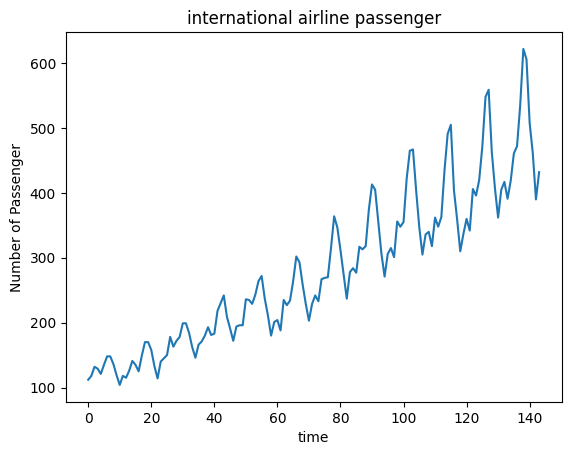

In [ ]:
plt.plot(dataset)
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("international airline passenger")
plt.show()

In [ ]:
#Scaling menjadi nilai 0..1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
dataset_scaled = scaler.fit_transform(dataset)

In [ ]:
#Split dataset untuk mendapatkan train dan test data. Bisa juga dibagi menjadi train, valid, dan test data.
train_size = int(len(dataset) * 0.60)
test_size = len(dataset) - train_size
train = dataset_scaled[0:train_size,:]
test = dataset_scaled[train_size:len(dataset),:]
print("train size: {}, test size: {} ".format(len(train), len(test)))

train size: 86, test size: 58 


In [ ]:
def createDataset(arr,window):
    x = []
    y = []
    for i in range(window, arr.shape[0]):
        x.append(arr[i-window:i, 0])
        y.append(arr[i, 0])
    x = np.array(x)
    y = np.array(y)
    return x,y

timestep=10
X_train, y_train = createDataset(train,timestep)
print(X_train.shape, y_train.shape)
X_test, y_test = createDataset(test,timestep)
print(X_test.shape, y_test.shape)

(76, 10) (76,)
(48, 10) (48,)


In [ ]:
X_train[1], y_train[1]

(array([0.02702703, 0.05405405, 0.04826255, 0.03281853, 0.05984556,
        0.08494208, 0.08494208, 0.06177606, 0.02895753, 0.        ]),
 np.float64(0.02702702702702703))

In [ ]:
#reshapes X_train to be 3-dimensional: (number of samples, number of timestep, 1)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print(X_train.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
print(X_test.shape)
X_train

(76, 10, 1)
(48, 10, 1)


array([[[0.01544402],
        [0.02702703],
        [0.05405405],
        [0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.08494208],
        [0.06177606],
        [0.02895753]],

       [[0.02702703],
        [0.05405405],
        [0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.08494208],
        [0.06177606],
        [0.02895753],
        [0.        ]],

       [[0.05405405],
        [0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.08494208],
        [0.06177606],
        [0.02895753],
        [0.        ],
        [0.02702703]],

       [[0.04826255],
        [0.03281853],
        [0.05984556],
        [0.08494208],
        [0.08494208],
        [0.06177606],
        [0.02895753],
        [0.        ],
        [0.02702703],
        [0.02123552]],

       [[0.03281853],
        [0.05984556],
        [0.08494208],
        [0.08494208],
        [0.06177606],
  

## 1. Pemodelan NN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0172
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0086 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048  
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0046 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 
Epoch 13/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 
Epoch 14/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 
Epoch 15/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 
Epoc

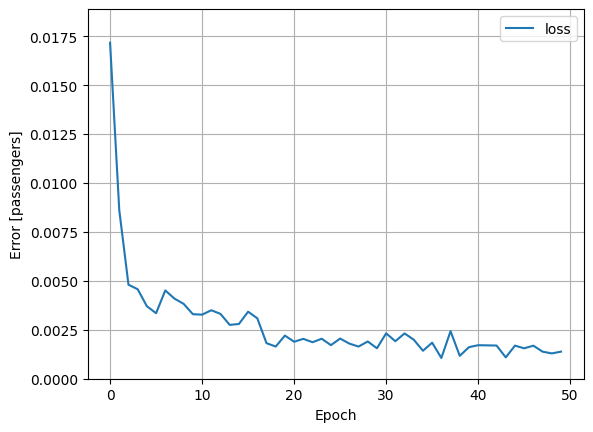

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
import matplotlib.pyplot as plt

# Initializing the Neural Network
regressor = Sequential()

# Adding the first Dense layer (fix input_shape)
regressor.add(Dense(units=100, activation='relu', input_shape=(X_train.shape[1],)))

# Adding a second Dense layer and Dropout
regressor.add(Dense(units=20, activation='relu'))
regressor.add(Dropout(0.2))

# Adding output layers (combine or separate based on intent)
regressor.add(Dense(units=8, activation='relu'))
regressor.add(Dense(units=1))

# Compiling the model
regressor.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))

# Fitting the model
history = regressor.fit(X_train, y_train, epochs=50, batch_size=8)

# Plotting the loss
plt.plot(history.history['loss'], label='loss')
plt.ylim([0, max(history.history['loss']) * 1.1])
plt.xlabel('Epoch')
plt.ylabel('Error [passengers]')  # Corrected typo: "passangers"
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
regressor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,893 (38.65 KB)

 Trainable params: 3,297 (12.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,596 (25.77 KB)

## 2. Evaluasi Model

In [ ]:
import math
from sklearn.metrics import mean_squared_error

trainPredictscaled = regressor.predict(X_train)
testPredictscaled = regressor.predict(X_test)
print(trainPredictscaled.shape, y_train.shape)
# invert predictions
trainPredict = scaler.inverse_transform(trainPredictscaled)
trainY = scaler.inverse_transform([y_train])
testPredict = scaler.inverse_transform(testPredictscaled)
testY = scaler.inverse_transform([y_test])
# # # calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(76, 1) (76,)
Train Score: 16.92 RMSE
Test Score: 48.25 RMSE


(76, 1)


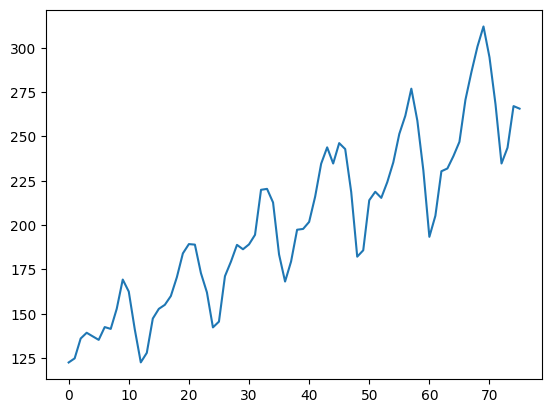

In [ ]:
print(trainPredict.shape)
plt.plot(trainPredict)

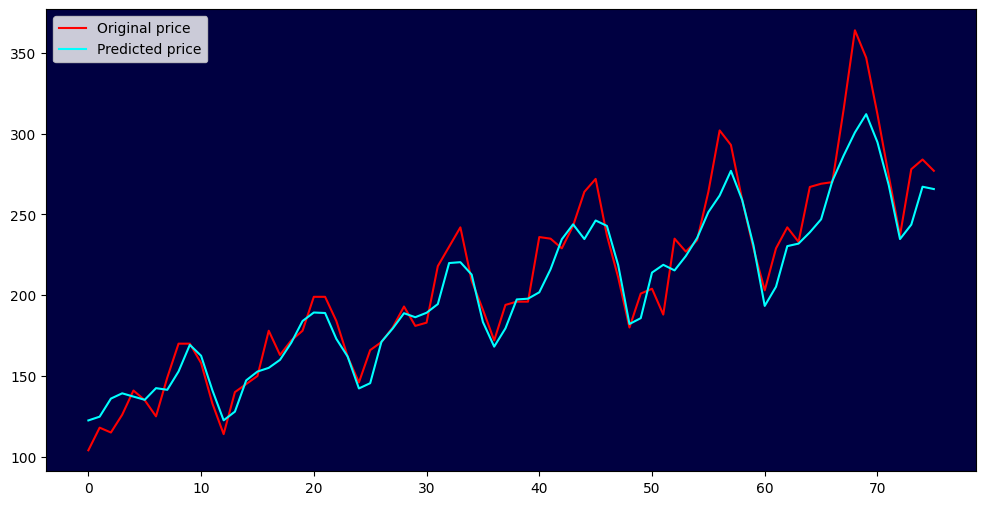

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
ax.set_facecolor('#000041')
ax.plot(trainY[0], color='red', label='Original price')
plt.plot(trainPredict[:,0], color='cyan', label='Predicted price')
plt.legend()

# Pemodelan RNN

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0452
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0182
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0100
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0066
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0056
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0053
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0034
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0033
Epoch 13/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 
Epoch 14/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031
Epoch 15/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0033
Epoch 16/50
10/10 ━━━━━

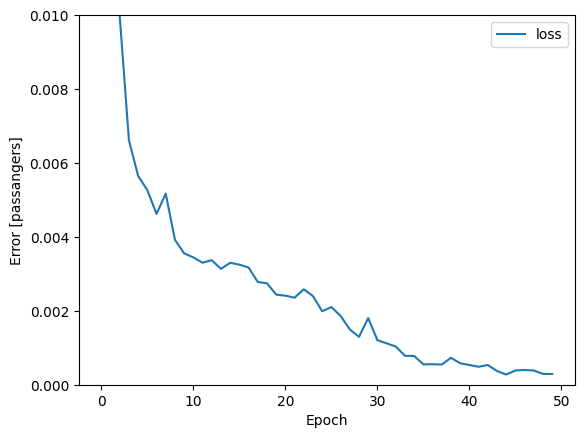

In [ ]:
# Importing the Keras libraries and packages
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout
from keras.optimizers import Adam

# Initialising the RNN
regressor = Sequential()

# Adding the first RNN layer
regressor.add(SimpleRNN(units = 100,activation='relu', return_sequences = True, input_shape = (X_train.shape[1], 1)))

# Adding a second RNN layer
regressor.add(SimpleRNN(units = 20, activation='relu'))

#Adding the output layer
regressor.add(Dense(units = 8, activation='relu'))
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))
history = regressor.fit(X_train, y_train, epochs=50, batch_size=8)
plt.plot(history.history['loss'], label='loss')
plt.ylim([0, 0.01])
plt.xlabel('Epoch')
plt.ylabel('Error [passangers]')
plt.legend()
# plt.grid(True)

In [ ]:
regressor.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 100)        │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20)             │         2,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,393 (149.98 KB)

 Trainable params: 12,797 (49.99 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,596 (99.99 KB)

In [ ]:
import math
from sklearn.metrics import mean_squared_error

trainPredictscaled = regressor.predict(X_train)
testPredictscaled = regressor.predict(X_test)
print(trainPredictscaled.shape, y_train.shape)
# invert predictions
trainPredict = scaler.inverse_transform(trainPredictscaled)
trainY = scaler.inverse_transform([y_train])
testPredict = scaler.inverse_transform(testPredictscaled)
testY = scaler.inverse_transform([y_test])
# # # calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(76, 1) (76,)
Train Score: 10.07 RMSE
Test Score: 21.87 RMSE


(76, 1)


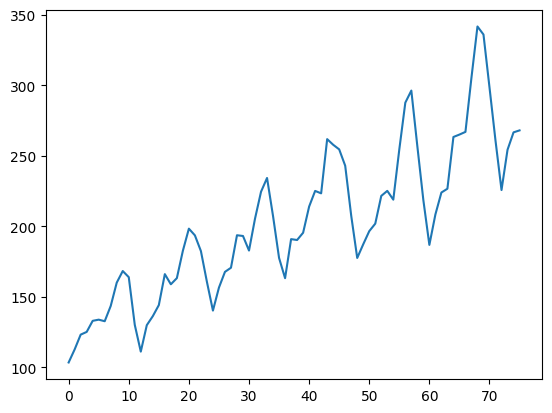

In [ ]:
print(trainPredict.shape)
plt.plot(trainPredict)

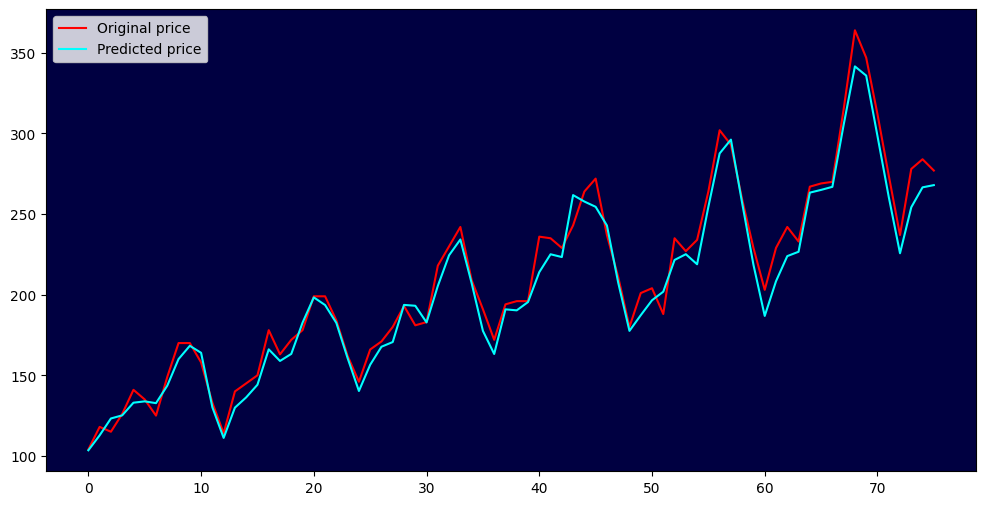

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
ax.set_facecolor('#000041')
ax.plot(trainY[0], color='red', label='Original price')
plt.plot(trainPredict[:,0], color='cyan', label='Predicted price')
plt.legend()

(Credit: I.S. Putri, 2025)

(Modified further by II4012 Assistants 2025/2026)